# TileStats: Hextile and Tile Binning

---

## Introduction


This notebook demonstrates the usage `hextile_bins`, `hextile_histogram`, `tile_bins`, and `tile_histogram` 
using randomly generated 2D points and simple visualizations.

----

## Setup

In [8]:
import math
import os
import random
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import matplotlib as mpl
mpl.rcParams.update({
    "axes.edgecolor": "silver",
    "axes.labelcolor": "silver",
    "xtick.color": "silver",
    "ytick.color": "silver",
    "text.color": "silver",
})

# Make the local package importable without installation
#sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

from TileStats import (
    hextile_bins,
    hextile_histogram,
    tile_bins,
    tile_histogram,
)

random.seed(7)

In [9]:
# Styling variables
points_color = '#2b6cb0'
hextile_cmap = 'Grays'
tile_cmap = 'Greens'
plot_bg = '#1f1f1f'
figure_bg = '#1f1f1f'

In [10]:
black_blue = LinearSegmentedColormap.from_list(
    "black_blue",
    ["#2F2F2F", "#0000ff"]
)

-----

## Random points

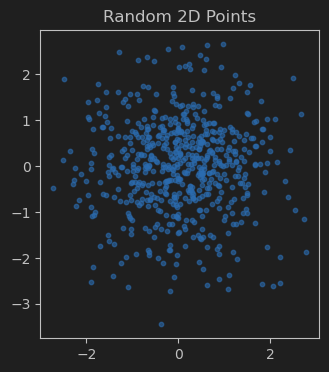

In [11]:
# Generate random 2D data points
n_points = 600
data = [(random.gauss(0, 1.0), random.gauss(0, 1.0)) for _ in range(n_points)]

xs = [p[0] for p in data]
ys = [p[1] for p in data]

plt.figure(figsize=(5, 4))
plt.scatter(xs, ys, s=10, alpha=0.6, color=points_color)
plt.title('Random 2D Points')
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
ax.set_facecolor(plot_bg)
ax.figure.set_facecolor(figure_bg)
#plt.show()

----

## Hextile bins

In [12]:
# Hextile bins (center keys)
hextile_bins = hextile_bins(data, bin_size=0.6, polygon_keys=False)

# Show a few bins and counts
list(hextile_bins.items())[:8]

[((-0.3, 0.5196152422706631), 23),
 ((-0.3, -0.5196152422706631), 23),
 ((-0.8999999999999999, -0.5196152422706631), 18),
 ((0.8999999999999999, 0.5196152422706631), 21),
 ((1.2, 0.0), 19),
 ((0.6, 0.0), 34),
 ((-1.7999999999999998, 1.0392304845413263), 8),
 ((0.3, 0.5196152422706631), 30)]

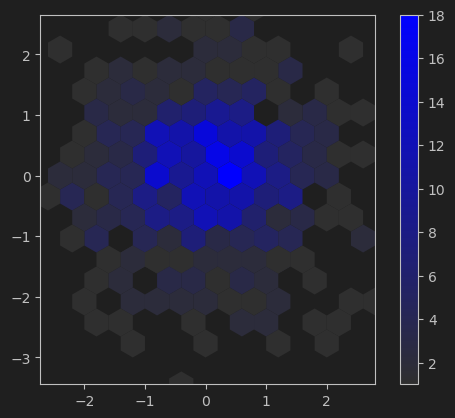

In [13]:
# Hextile histogram (colored polygons)
hex_hist = hextile_histogram(
    data,
    bin_size=0.4,
    histogram_type='ColoredPolygons',
    plot=True,
    plot_legends='Automatic',
    color_function=black_blue, #hextile_cmap,
    facecolor=plot_bg,
)
hex_hist['figure'].set_facecolor(plot_bg)
#fig = hex_hist['figure']

----

## Tile bins

In [14]:
# Rectangular tile bins (center keys)
tile_bins = tile_bins(data, bin_size=0.8, polygon_keys=False)

# Show a few bins and counts
list(tile_bins.items())[:8]

[((-0.4, 0.4), 54),
 ((-0.4, -0.4), 50),
 ((-1.2000000000000002, -0.4), 30),
 ((1.2000000000000002, 0.4), 36),
 ((0.4, 0.4), 65),
 ((-2.0000000000000004, 1.2000000000000002), 8),
 ((-2.0000000000000004, -2.0000000000000004), 2),
 ((0.4, -0.4), 52)]

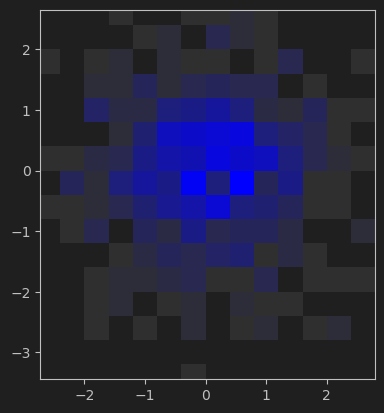

In [15]:
# Tile histogram (colored polygons)
tile_hist = tile_histogram(
    data,
    bin_size=0.4,
    histogram_type='ColoredPolygons',
    plot=True,
    color_function= black_blue, #tile_cmap,
    facecolor=plot_bg,
)
tile_hist['figure'].set_facecolor(plot_bg)
#fig = tile_hist['figure']

----

## References

[AAp1] Anton Antonov, [TileStats, Python package](https://pypi.org/project/TileStats), (2026), [PyPI.org](https://pypi.org).

[AAp2] Anton Antonov, [TileStats, Wolfram Language paclet](https://resources.wolframcloud.com/PacletRepository/resources/AntonAntonov/TileStats/), (2023), [Wolfram Language Paclet Repository](https://resources.wolframcloud.com/PacletRepository).

[AAp3] Anton Antonov, [TileStats, Java package](https://github.com/antononcube/Java-TileStats), (2023), [GitHub/antononcube](https://github.com/antononcube).